EXPERIMENT 06 - TASK 03
Clustering Performance and PCA Comparison
Name    : R. Karthik
Roll No : 25EU02904

Original Feature Space: (150, 4)
PCA Feature Space: (150, 2)

Variance Retained by PCA: 95.81%

Clustering Performance Comparison:
                      Space  Silhouette Score  Calinski-Harabasz  Adjusted Rand Index  Normalized Mutual Info
Standardized Raw Space (4D)            0.4599           241.9044               0.6201                  0.6595
     PCA Reduced Space (2D)            0.5092           293.8565               0.6201                  0.6595


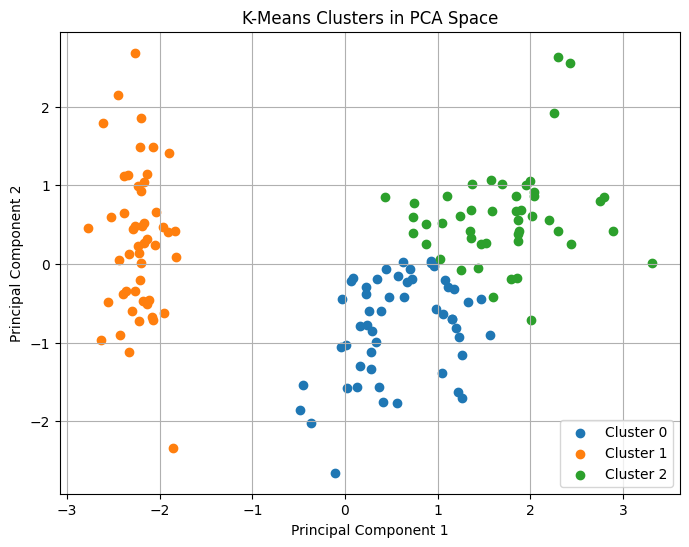

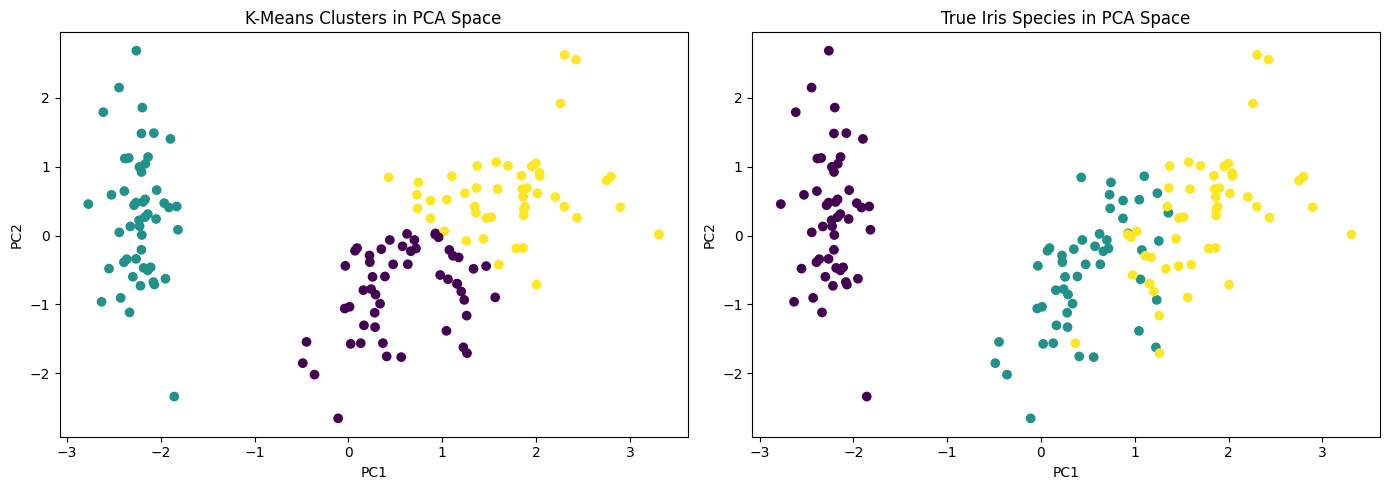


Interpretation:
PCA space provides a higher Silhouette Score, indicating improved cluster separation.
PCA reduces the feature space from 4 dimensions to 2 dimensions while retaining most of the important information.

TASK 03 COMPLETED SUCCESSFULLY
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 06 - TASK 03
# Clustering Performance and PCA Space Comparison
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

print("=" * 60)
print("EXPERIMENT 06 - TASK 03")
print("Clustering Performance and PCA Comparison")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load Iris Dataset
# ------------------------------------------------------------

iris = load_iris()

X = iris.data

y = iris.target

target_names = iris.target_names

# ------------------------------------------------------------
# 2. Standardize Features
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

# ------------------------------------------------------------
# 3. PCA Transformation
# ------------------------------------------------------------

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

print(
    "\nOriginal Feature Space:",
    X_scaled.shape
)

print(
    "PCA Feature Space:",
    X_pca.shape
)

print(
    "\nVariance Retained by PCA:",
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

# ------------------------------------------------------------
# 4. K-Means on Raw 4D Space
# ------------------------------------------------------------

kmeans_raw = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    random_state=42
)

raw_labels = kmeans_raw.fit_predict(
    X_scaled
)

# ------------------------------------------------------------
# 5. K-Means on PCA 2D Space
# ------------------------------------------------------------

kmeans_pca = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    random_state=42
)

pca_labels = kmeans_pca.fit_predict(
    X_pca
)

# ------------------------------------------------------------
# 6. Raw Space Metrics
# ------------------------------------------------------------

sil_raw = silhouette_score(
    X_scaled,
    raw_labels
)

ch_raw = calinski_harabasz_score(
    X_scaled,
    raw_labels
)

ari_raw = adjusted_rand_score(
    y,
    raw_labels
)

nmi_raw = normalized_mutual_info_score(
    y,
    raw_labels
)

# ------------------------------------------------------------
# 7. PCA Space Metrics
# ------------------------------------------------------------

sil_pca = silhouette_score(
    X_pca,
    pca_labels
)

ch_pca = calinski_harabasz_score(
    X_pca,
    pca_labels
)

ari_pca = adjusted_rand_score(
    y,
    pca_labels
)

nmi_pca = normalized_mutual_info_score(
    y,
    pca_labels
)

# ------------------------------------------------------------
# 8. Comparison Table
# ------------------------------------------------------------

comparison = pd.DataFrame(
    {
        "Space": [
            "Standardized Raw Space (4D)",
            "PCA Reduced Space (2D)"
        ],
        "Silhouette Score": [
            sil_raw,
            sil_pca
        ],
        "Calinski-Harabasz": [
            ch_raw,
            ch_pca
        ],
        "Adjusted Rand Index": [
            ari_raw,
            ari_pca
        ],
        "Normalized Mutual Info": [
            nmi_raw,
            nmi_pca
        ]
    }
)

print("\nClustering Performance Comparison:")
print(
    comparison.round(4).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 9. PCA Visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

for cluster in range(3):

    mask = pca_labels == cluster

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}"
    )

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "K-Means Clusters in PCA Space"
)

plt.legend()

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 10. True Labels vs Clusters
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# K-Means clusters
scatter1 = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=pca_labels
)

axes[0].set_title(
    "K-Means Clusters in PCA Space"
)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# True species
scatter2 = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y
)

axes[1].set_title(
    "True Iris Species in PCA Space"
)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 11. Interpretation
# ------------------------------------------------------------

print("\nInterpretation:")

if sil_pca > sil_raw:
    print(
        "PCA space provides a higher Silhouette Score, "
        "indicating improved cluster separation."
    )
else:
    print(
        "The standardized raw space provides a higher "
        "Silhouette Score."
    )

print(
    "PCA reduces the feature space from 4 dimensions "
    "to 2 dimensions while retaining most of the "
    "important information."
)

# ------------------------------------------------------------
# Conclusion
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK 03 COMPLETED SUCCESSFULLY")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)